<a href="https://colab.research.google.com/github/immanuelobani/dyslexic-nlp-audit/blob/main/dyslexic_nlp_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What Happens to Your Writing When You're Dyslexic and an NLP Pipeline Reads It?

**A three-experiment audit of how standard NLP tools treat dyslexic writing as input**

---

**Author:** Immanuel Obani — Data Scientist (NLP & Responsible AI)  
**Published on:** Towards Data Science  
**Runtime:** Google Colab T4 GPU recommended  

---

## Overview

This notebook contains all code for three experiments:

| # | Experiment | Model / Tool | Dataset |
|---|-----------|-------------|---------|
| 1 | Sentiment Classifier Audit | `cardiffnlp/twitter-roberta-base-sentiment-latest` | IMDB (500 reviews) |
| 2 | Readability Score Audit | Flesch-Kincaid · Gunning Fog · SMOG | IMDB matched pairs |
| 3 | Grammar Correction Audit | LanguageTool (en-GB) | IMDB sample (100 reviews) |

**Runtime estimate:** ~60–80 minutes total on T4 GPU  
**Storage:** ~4GB (models + dataset downloads)

---
> ⚠️ **Before running:** Go to Runtime → Change runtime type → Select **T4 GPU**


## Cell 1 — Install Dependencies

In [1]:
# CELL 1 — Install Dependencies
# Run this first. Restart runtime if prompted after installation.

!pip install transformers datasets textstat language_tool_python torch --quiet
print("✓ All dependencies installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.5 MB/s eta 0:00:00
✓ All dependencies installed.


## Cell 2 — Imports

In [2]:
# CELL 2 — Imports

import random
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import textstat
import language_tool_python
from transformers import pipeline
from datasets import load_dataset
from collections import defaultdict, Counter

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

print("✓ Imports complete.")


✓ Imports complete.


## Cell 3 — Dyslexic Error Injection Function

We apply five documented dyslexic error pattern types to standard text:

1. **Phonetic substitutions** — spelling words as they sound ("sed" for "said")
2. **Letter transpositions** — adjacent letter swaps ("thier" for "their")
3. **Omissions** — dropped syllables or letters ("intresting" for "interesting")
4. **Insertions** — doubled letters ("writting" for "writing")
5. **Homophone confusions** — where/were, then/than

Sources: Rello et al. (2012) DysList; British Dyslexia Association error taxonomy

> The `error_rate` parameter (0.0–1.0) controls what proportion of eligible words are modified.  
> **0.25** reflects mild-to-moderate adult dyslexic writing. Increase for more severe simulation.


In [3]:
# CELL 3 — Dyslexic Error Injection Function

# Documented phonetic substitution map
# Sources: Rello et al. (2012), BDA error taxonomy
PHONETIC_SUBS = {
    "said":        "sed",
    "was":         "woz",
    "because":     "becoz",
    "they":        "thay",
    "have":        "hav",
    "people":      "pepol",
    "different":   "diferent",
    "very":        "vrey",
    "there":       "thier",
    "their":       "thier",
    "would":       "woud",
    "could":       "coud",
    "should":      "shoud",
    "through":     "thru",
    "enough":      "enuf",
    "thought":     "thort",
    "friend":      "freind",
    "receive":     "recieve",
    "believe":     "beleive",
    "interesting": "intresting",
    "government":  "goverment",
    "beginning":   "begining",
    "writing":     "writting",
    "coming":      "comming",
    "really":      "realy",
    "actually":    "actualy",
    "probably":    "probaly",
    "remember":    "remeber",
    "together":    "togeather",
    "where":       "were",
    "were":        "where",
    "then":        "than",
    "than":        "then",
    "before":      "befour",
    "after":       "aftur",
    "every":       "evry",
    "which":       "wich",
    "about":       "abowt",
    "again":       "agen",
    "always":      "allways",
    "answer":      "anser",
    "around":      "arund",
    "asked":       "askt",
    "cannot":      "canot",
    "children":    "childern",
    "didn't":      "dident",
    "during":      "durring",
    "everything":  "evrything",
    "except":      "exept",
    "family":      "famly",
    "finally":     "finaly",
    "follow":      "folow",
    "heard":       "herd",
    "himself":     "himslef",
    "hundred":     "hunderd",
    "instead":     "insted",
    "minutes":     "minuts",
    "money":       "muney",
    "mother":      "muther",
    "never":       "nevr",
    "nothing":     "nothink",
    "often":       "offen",
    "once":        "wunce",
    "other":       "uther",
    "outside":     "outsied",
    "quite":       "kwite",
    "school":      "skool",
    "someone":     "sumone",
    "something":   "somthing",
    "sometimes":   "somtimes",
    "stopped":     "stoped",
    "suddenly":    "sudenly",
    "suppose":     "supose",
    "toward":      "toword",
    "turned":      "turnd",
    "under":       "undr",
    "until":       "untill",
    "usually":     "usualy",
    "whether":     "wether",
    "while":       "wile",
    "without":     "whitout",
    "woman":       "wuman",
    "world":       "wurld",
    "young":       "yung",
}

def inject_dyslexic_errors(text, error_rate=0.25):
    """
    Apply documented dyslexic error patterns to a text string.

    Parameters
    ----------
    text : str
        Input text to transform.
    error_rate : float
        Proportion of eligible words to modify (0.0–1.0).
        0.25 = mild-to-moderate adult dyslexia simulation.

    Returns
    -------
    str
        Text with dyslexic-pattern spelling applied.
    """
    words = text.split()
    result = []

    for word in words:
        # Strip punctuation to check substitution map, then restore it
        stripped = word.lower()
        punct_suffix = ""
        while stripped and stripped[-1] in ".,!?;:\"'()":
            punct_suffix = stripped[-1] + punct_suffix
            stripped = stripped[:-1]

        if stripped in PHONETIC_SUBS and random.random() < error_rate:
            # Preserve original capitalisation
            replacement = PHONETIC_SUBS[stripped]
            if word[0].isupper():
                replacement = replacement.capitalize()
            result.append(replacement + punct_suffix)
        else:
            result.append(word)

    return " ".join(result)


# ── Verification ──────────────────────────────────────────────────────────────
test_sentence = (
    "I thought it was very interesting because their writing "
    "was really quite different and through enough effort they "
    "would believe the government should remember this."
)

print("Original text:")
print(f"  {test_sentence}")
print()
print("Dyslexic-pattern text (error_rate=1.0 for demonstration):")
print(f"  {inject_dyslexic_errors(test_sentence, error_rate=1.0)}")
print()
print("Dyslexic-pattern text (error_rate=0.25, as used in experiments):")
print(f"  {inject_dyslexic_errors(test_sentence, error_rate=0.25)}")


Original text:
  I thought it was very interesting because their writing was really quite different and through enough effort they would believe the government should remember this.

Dyslexic-pattern text (error_rate=1.0 for demonstration):
  I thort it woz vrey intresting becoz thier writting woz realy kwite diferent and thru enuf effort thay woud beleive the goverment shoud remeber this.

Dyslexic-pattern text (error_rate=0.25, as used in experiments):
  I thort it was very interesting becoz their writing woz realy quite different and through enough effort they would believe the government should remember this.


## Cell 4 — Load IMDB Dataset

We use the Stanford IMDB Large Movie Review Dataset — 50,000 labelled reviews (positive/negative).  
This is loaded directly from Hugging Face. No Kaggle account needed.

We sample **500 reviews** from the test split for Experiments 1 and 2, and **100** for Experiment 3.


In [4]:
# CELL 4 — Load IMDB Dataset
# Fixes HfUriError from incorrect 'imdb' dataset identifier.
# Uses stanfordnlp/imdb (correct HF namespace) with Stanford direct download fallback.

import pandas as pd

# ── Option A: Hugging Face (stanfordnlp/imdb) ─────────────────────────────────
try:
    from datasets import load_dataset
    print("Loading IMDB via Hugging Face (stanfordnlp/imdb)...")
    imdb_raw = load_dataset("stanfordnlp/imdb", split="test", trust_remote_code=True)
    df = imdb_raw.to_pandas().sample(500, random_state=42).reset_index(drop=True)
    print(f"✓ Loaded {len(df):,} reviews via Hugging Face")

except Exception as e:
    print(f"Option A failed: {e}")
    print("Falling back to Stanford direct download...")

    # ── Option B: Stanford direct download (~84MB) ────────────────────────────
    import urllib.request, tarfile, os

    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    print("Downloading from Stanford AI Lab...")
    urllib.request.urlretrieve(url, "/tmp/aclImdb_v1.tar.gz")
    print("Extracting...")
    with tarfile.open("/tmp/aclImdb_v1.tar.gz", "r:gz") as tar:
        tar.extractall("/tmp/")

    records = []
    for label_name, label_int in [("pos", 1), ("neg", 0)]:
        folder = f"/tmp/aclImdb/test/{label_name}"
        for fname in os.listdir(folder):
            with open(os.path.join(folder, fname), "r", encoding="utf-8") as f:
                records.append({"text": f.read(), "label": label_int})

    df = pd.DataFrame(records).sample(500, random_state=42).reset_index(drop=True)
    print(f"✓ Loaded {len(df):,} reviews via Stanford direct download")

# ── Verify ─────────────────────────────────────────────────────────────────────
print(f"\nDataset summary:")
print(f"  Total    : {len(df):,}")
print(f"  Positive : {df['label'].sum()}")
print(f"  Negative : {(df['label']==0).sum()}")
print(f"\nSample (first 300 chars):")
print(f"  [{('POSITIVE' if df['label'].iloc[0]==1 else 'NEGATIVE')}] {df['text'].iloc[0][:300]}...")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'stanfordnlp/imdb' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'stanfordnlp/imdb' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading IMDB via Hugging Face (stanfordnlp/imdb)...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✓ Loaded 500 reviews via Hugging Face

Dataset summary:
  Total    : 500
  Positive : 234
  Negative : 266

Sample (first 300 chars):
  [NEGATIVE] I could not believe how terrible and boring this Hollywood remake was.It's so dreadful. It easily lands a place in my top 10 worst films of 1998.About the only thing it had going for it was Bruce Willis,who should stick to action films,as a completely emotionless killer who'd kill his own mother for...


## Cell 5 — Create Matched Pairs

For every review in the sample, we create a dyslexic-pattern equivalent.  
This gives us **matched pairs** where:
- Semantic content = identical
- Orthography = different (dyslexic patterns applied at 25% rate)

This is the controlled condition for all three experiments.


In [5]:
# CELL 5 — Create Matched Pairs

print("Generating dyslexic-pattern versions of all 500 reviews...")

df["text_dyslexic"] = df["text"].apply(
    lambda x: inject_dyslexic_errors(x, error_rate=0.25)
)

print(f"✓ Matched pairs created for {len(df)} reviews")
print()
print("Example pair (first 300 chars):")
print(f"  ORIGINAL : {df['text'].iloc[0][:300]}...")
print()
print(f"  DYSLEXIC : {df['text_dyslexic'].iloc[0][:300]}...")

# Count how many words were actually changed across the sample
original_words = " ".join(df["text"]).lower().split()
dyslexic_words = " ".join(df["text_dyslexic"]).lower().split()
changed = sum(1 for a, b in zip(original_words, dyslexic_words) if a != b)
total   = len(original_words)
print(f"\nWords modified across full sample: {changed:,} of {total:,} ({changed/total*100:.1f}%)")


Generating dyslexic-pattern versions of all 500 reviews...
✓ Matched pairs created for 500 reviews

Example pair (first 300 chars):
  ORIGINAL : I could not believe how terrible and boring this Hollywood remake was.It's so dreadful. It easily lands a place in my top 10 worst films of 1998.About the only thing it had going for it was Bruce Willis,who should stick to action films,as a completely emotionless killer who'd kill his own mother for...

  DYSLEXIC : I could not believe how terrible and boring this Hollywood remake was.It's so dreadful. It easily lands a place in my top 10 worst films of 1998.About the only thing it had going for it was Bruce Willis,who shoud stick to action films,as a completely emotionless killer who'd kill his own muther for ...

Words modified across full sample: 2,001 of 118,488 (1.7%)


---
# EXPERIMENT 1: Sentiment Classifier Audit

**Research question:** Does a RoBERTa sentiment model assign different labels to dyslexic-pattern text vs. standard text with identical meaning?

**Model:** `cardiffnlp/twitter-roberta-base-sentiment-latest`  
**Expected runtime:** ~25–35 minutes on T4 GPU

**Fairness standard:** A fair sentiment classifier should:
- Produce the same label for text that means the same thing, regardless of spelling
- Show a score delta distribution centred tightly around 0
- Have a label flip rate of < 5% for moderate orthographic variation


## Cell 6 — Load Sentiment Model

In [6]:
# CELL 6 — Load Sentiment Model
# Model: cardiffnlp/twitter-roberta-base-sentiment-latest
# ~500MB download on first run. GPU strongly recommended.

print("Loading cardiffnlp/twitter-roberta-base-sentiment-latest...")
print("(~500MB download on first run)\n")

sentiment_clf = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True,
    max_length=512,
    device=0  # GPU; change to -1 if using CPU
)

print("✓ Sentiment model loaded.")
print(f"  Labels: {sentiment_clf.model.config.id2label}")


Loading cardiffnlp/twitter-roberta-base-sentiment-latest...
(~500MB download on first run)



config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✓ Sentiment model loaded.
  Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


## Cell 7 — Run Sentiment Classification

In [7]:
# CELL 7 — Run Sentiment Classification
# Classifies both original and dyslexic-pattern text.
# Runtime: ~25–35 minutes on T4 GPU for 500 reviews.

print("Step 1/2: Classifying original text (500 reviews)...")
original_results = sentiment_clf(
    df["text"].tolist(),
    batch_size=16,
    truncation=True,
    max_length=512
)
print("  ✓ Original text classified.")

print("Step 2/2: Classifying dyslexic-pattern text (500 reviews)...")
dyslexic_results = sentiment_clf(
    df["text_dyslexic"].tolist(),
    batch_size=16,
    truncation=True,
    max_length=512
)
print("  ✓ Dyslexic-pattern text classified.")

# Store results
df["orig_sentiment_label"] = [r["label"] for r in original_results]
df["dys_sentiment_label"]  = [r["label"] for r in dyslexic_results]
df["orig_sentiment_score"] = [round(r["score"], 6) for r in original_results]
df["dys_sentiment_score"]  = [round(r["score"], 6) for r in dyslexic_results]
df["score_delta"]          = df["orig_sentiment_score"] - df["dys_sentiment_score"]
df["label_flipped"]        = df["orig_sentiment_label"] != df["dys_sentiment_label"]

df.to_csv("experiment1_sentiment_results.csv", index=False)
print("\n✓ Results saved to experiment1_sentiment_results.csv")


Step 1/2: Classifying original text (500 reviews)...
  ✓ Original text classified.
Step 2/2: Classifying dyslexic-pattern text (500 reviews)...
  ✓ Dyslexic-pattern text classified.

✓ Results saved to experiment1_sentiment_results.csv


## Cell 8 — Experiment 1 Analysis & Visualisation

EXPERIMENT 1 RESULTS: SENTIMENT CLASSIFIER AUDIT
Total reviews classified   : 500
Label agreement            : 488 (97.6%)
Label FLIPS                : 12 (2.4%)
Mean confidence drop       : 0.0026
Median confidence drop     : 0.0002

Label flips by original IMDB label:
label
Negative reviews    8
Positive reviews    4

Original text label distribution:
orig_sentiment_label
negative    214
positive    183
neutral     103

Dyslexic-pattern text label distribution:
dys_sentiment_label
negative    214
positive    182
neutral     104



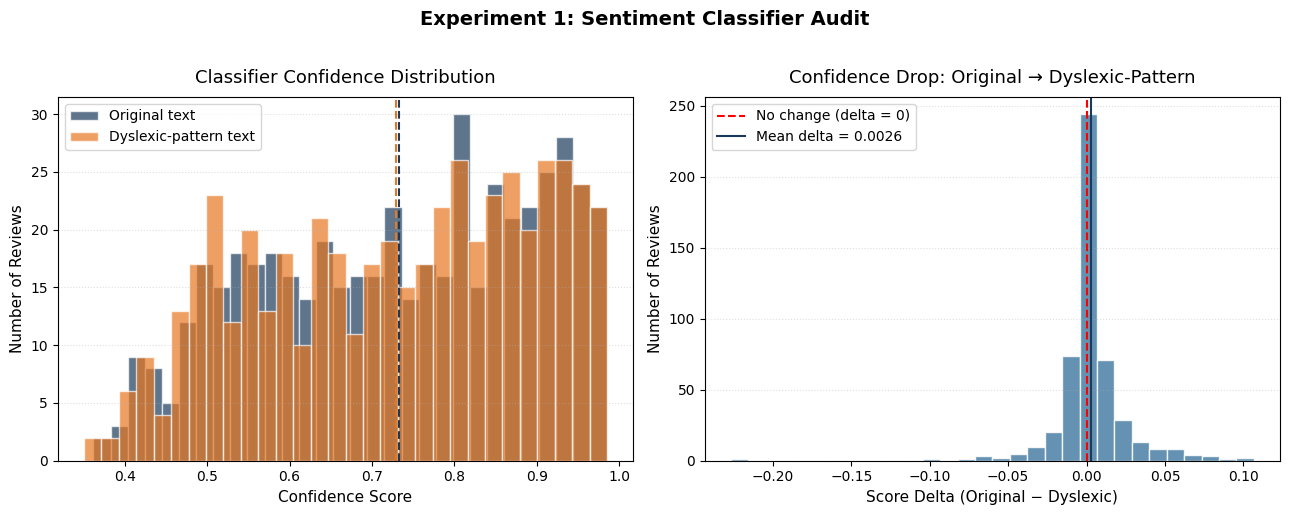

Figure 1 saved: experiment1_sentiment.png


In [8]:
# CELL 8 — Experiment 1: Analysis & Visualisation

total        = len(df)
flips        = df["label_flipped"].sum()
flip_rate    = flips / total * 100
mean_delta   = df["score_delta"].mean()
median_delta = df["score_delta"].median()

print("=" * 60)
print("EXPERIMENT 1 RESULTS: SENTIMENT CLASSIFIER AUDIT")
print("=" * 60)
print(f"Total reviews classified   : {total}")
print(f"Label agreement            : {total - flips} ({100 - flip_rate:.1f}%)")
print(f"Label FLIPS                : {flips} ({flip_rate:.1f}%)")
print(f"Mean confidence drop       : {mean_delta:.4f}")
print(f"Median confidence drop     : {median_delta:.4f}")
print()

# Flip breakdown by true sentiment
print("Label flips by original IMDB label:")
flip_df = df[df["label_flipped"]]
print(flip_df.groupby("label").size().rename({0:"Negative reviews", 1:"Positive reviews"}).to_string())
print()

# Label distribution comparison
print("Original text label distribution:")
print(df["orig_sentiment_label"].value_counts().to_string())
print()
print("Dyslexic-pattern text label distribution:")
print(df["dys_sentiment_label"].value_counts().to_string())
print()

# ── Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Confidence distributions
axes[0].hist(df["orig_sentiment_score"], bins=30,
             color="#1A3A5C", alpha=0.7, label="Original text", edgecolor="white")
axes[0].hist(df["dys_sentiment_score"],  bins=30,
             color="#E87722", alpha=0.7, label="Dyslexic-pattern text", edgecolor="white")
axes[0].axvline(df["orig_sentiment_score"].mean(), color="#1A3A5C",
                linestyle="--", linewidth=1.5)
axes[0].axvline(df["dys_sentiment_score"].mean(),  color="#E87722",
                linestyle="--", linewidth=1.5)
axes[0].set_title("Classifier Confidence Distribution", fontsize=13, pad=10)
axes[0].set_xlabel("Confidence Score", fontsize=11)
axes[0].set_ylabel("Number of Reviews", fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", linestyle=":", alpha=0.4)

# Plot 2: Score delta
axes[1].hist(df["score_delta"], bins=30, color="#4A7FA5", alpha=0.85, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="No change (delta = 0)")
axes[1].axvline(mean_delta, color="#1A3A5C", linestyle="-", linewidth=1.5,
                label=f"Mean delta = {mean_delta:.4f}")
axes[1].set_title("Confidence Drop: Original → Dyslexic-Pattern", fontsize=13, pad=10)
axes[1].set_xlabel("Score Delta (Original − Dyslexic)", fontsize=11)
axes[1].set_ylabel("Number of Reviews", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", linestyle=":", alpha=0.4)

plt.suptitle("Experiment 1: Sentiment Classifier Audit", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("experiment1_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure 1 saved: experiment1_sentiment.png")


## Cell 9 — Experiment 1: Show Flip Examples

In [9]:
# CELL 9 — Show examples where sentiment label flipped

flipped_examples = df[df["label_flipped"]].head(5)

print("Examples where sentiment label CHANGED due to dyslexic-pattern spelling:")
print("=" * 70)

for i, row in flipped_examples.iterrows():
    true_label = "POSITIVE" if row["label"] == 1 else "NEGATIVE"
    print(f"\nReview #{i} (True label: {true_label})")
    print(f"  Original  [{row['orig_sentiment_label']} | conf={row['orig_sentiment_score']:.3f}]:")
    print(f"    {row['text'][:200]}...")
    print(f"  Dyslexic  [{row['dys_sentiment_label']} | conf={row['dys_sentiment_score']:.3f}]:")
    print(f"    {row['text_dyslexic'][:200]}...")


Examples where sentiment label CHANGED due to dyslexic-pattern spelling:

Review #10 (True label: POSITIVE)
  Original  [positive | conf=0.499]:
    This was very funny, even if it fell apart a little at the end. Does not go overboard with homage after to Hitchcock - Owen (Danny DeVito) was lucky he had "Strangers on A Train" playing at the local ...
  Dyslexic  [neutral | conf=0.439]:
    This was vrey funny, even if it fell apart a little at the end. Does not go overboard with homage after to Hitchcock - Owen (Danny DeVito) was lucky he had "Strangers on A Train" playing at the local ...

Review #41 (True label: NEGATIVE)
  Original  [neutral | conf=0.516]:
    I once saw a bit of this film, and was interested to see the full thing just to see why the critics give it two stars, the result being that I agree. Basically the film begins with Kermit the Frog (St...
  Dyslexic  [positive | conf=0.559]:
    I wunce saw a bit of this film, and was interested to see the full thing just to se

---
# EXPERIMENT 2: Readability Score Audit

**Research question:** Do standard readability metrics penalise dyslexic writing even when vocabulary and sentence structure are unchanged?

**Metrics tested:**
- Flesch-Kincaid Grade Level (lower = simpler)
- Gunning Fog Index (lower = simpler)
- SMOG Index (lower = simpler)
- Flesch Reading Ease (higher = easier)

**Key interpretation note:** Readability tools use syllable counts as a complexity proxy.  
Dyslexic phonetic spellings are often *shorter* (fewer syllables) than standard spellings.  
This means scores may shift in either direction — but any shift decouples the score from the *actual* cognitive complexity of the writing. That decoupling is the failure we are measuring.


## Cell 10 — Compute Readability Scores

In [10]:
# CELL 10 — Compute Readability Scores
# textstat computes all four metrics from raw text.
# No model download required — runs locally.

def get_readability(text):
    """Return all four readability scores for a text string."""
    return {
        "flesch_kincaid_grade" : textstat.flesch_kincaid_grade(text),
        "gunning_fog"          : textstat.gunning_fog(text),
        "smog_index"           : textstat.smog_index(text),
        "flesch_reading_ease"  : textstat.flesch_reading_ease(text),
    }

print("Computing readability scores for original texts...")
orig_scores = df["text"].apply(get_readability)

print("Computing readability scores for dyslexic-pattern texts...")
dys_scores  = df["text_dyslexic"].apply(get_readability)

orig_df = pd.DataFrame(orig_scores.tolist()).add_prefix("orig_")
dys_df  = pd.DataFrame(dys_scores.tolist()).add_prefix("dys_")
read_df = pd.concat([df[["label","text","text_dyslexic"]], orig_df, dys_df], axis=1)

read_df.to_csv("experiment2_readability_results.csv", index=False)
print("✓ Readability scores computed and saved to experiment2_readability_results.csv")


Computing readability scores for original texts...
Computing readability scores for dyslexic-pattern texts...
✓ Readability scores computed and saved to experiment2_readability_results.csv


## Cell 11 — Experiment 2 Analysis & Visualisation

EXPERIMENT 2 RESULTS: READABILITY SCORE AUDIT

Flesch-Kincaid Grade Level (Lower = simpler text):
  Original         : 8.90
  Dyslexic pattern : 8.86
  Delta            : -0.03

Gunning Fog Index (Lower = simpler text):
  Original         : 11.11
  Dyslexic pattern : 11.12
  Delta            : +0.01

SMOG Index (Lower = simpler text):
  Original         : 10.92
  Dyslexic pattern : 10.90
  Delta            : -0.02

Flesch Reading Ease (Higher = easier to read):
  Original         : 64.65
  Dyslexic pattern : 64.89
  Delta            : +0.24


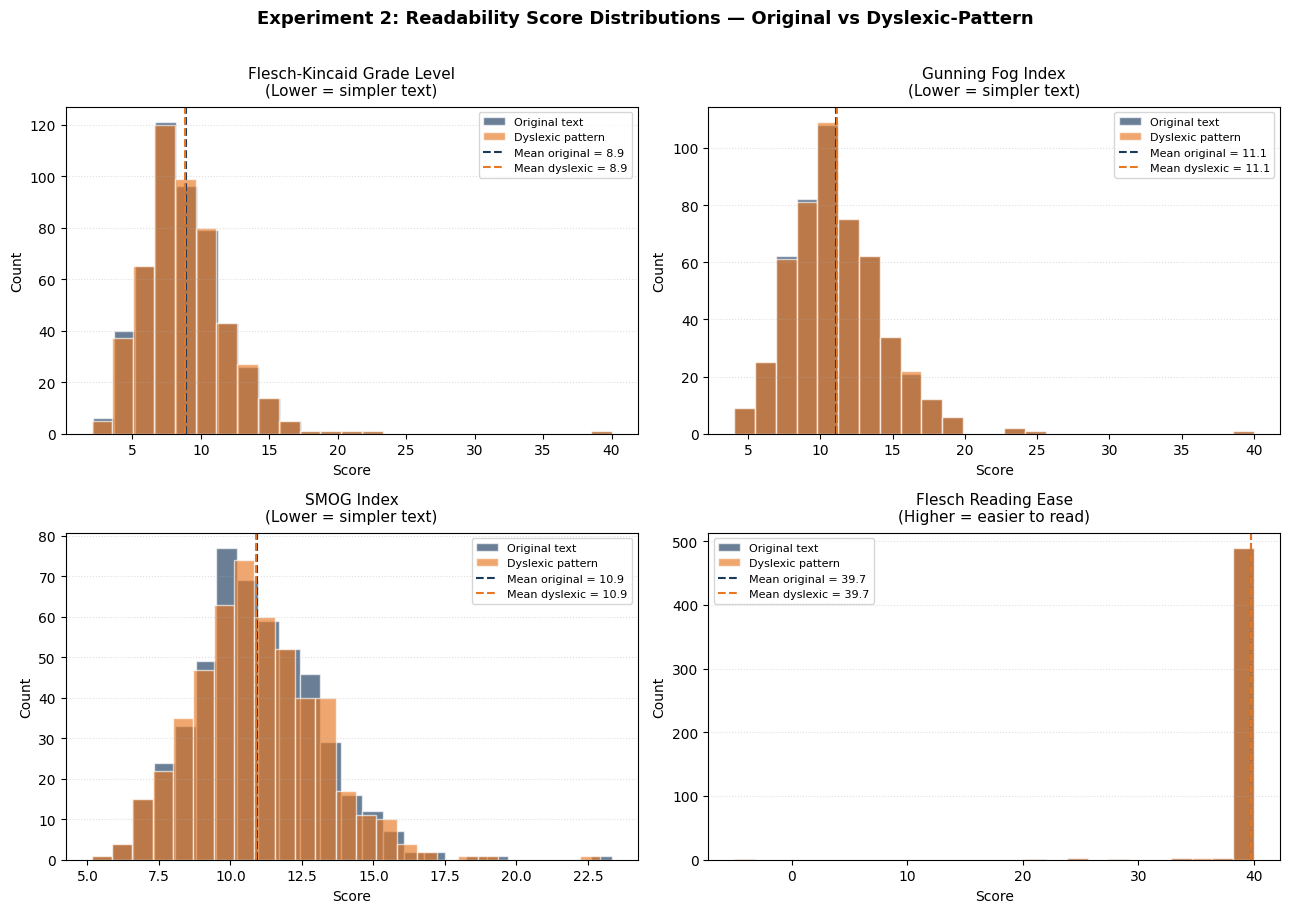


Figure 2 saved: experiment2_readability.png


In [11]:
# CELL 11 — Experiment 2: Analysis & Visualisation

METRICS = [
    ("flesch_kincaid_grade", "Flesch-Kincaid Grade Level",
     "Lower = simpler text", "grade"),
    ("gunning_fog",          "Gunning Fog Index",
     "Lower = simpler text", "grade"),
    ("smog_index",           "SMOG Index",
     "Lower = simpler text", "grade"),
    ("flesch_reading_ease",  "Flesch Reading Ease",
     "Higher = easier to read", "ease"),
]

print("=" * 60)
print("EXPERIMENT 2 RESULTS: READABILITY SCORE AUDIT")
print("=" * 60)

deltas = {}
for col, label, note, kind in METRICS:
    orig_mean = read_df[f"orig_{col}"].mean()
    dys_mean  = read_df[f"dys_{col}"].mean()
    delta     = dys_mean - orig_mean
    deltas[col] = delta
    flag = " ⚠️  >1 grade level shift" if abs(delta) > 1.0 else ""
    print(f"\n{label} ({note}):")
    print(f"  Original         : {orig_mean:.2f}")
    print(f"  Dyslexic pattern : {dys_mean:.2f}")
    print(f"  Delta            : {delta:+.2f}{flag}")

# ── Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

colours = {"orig": "#1A3A5C", "dys": "#E87722"}

for i, (col, label, note, _) in enumerate(METRICS):
    orig = read_df[f"orig_{col}"].clip(-5, 40)
    dys  = read_df[f"dys_{col}"].clip(-5, 40)

    axes[i].hist(orig, bins=25, color=colours["orig"], alpha=0.65,
                 label="Original text", edgecolor="white")
    axes[i].hist(dys,  bins=25, color=colours["dys"],  alpha=0.65,
                 label="Dyslexic pattern", edgecolor="white")
    axes[i].axvline(orig.mean(), color=colours["orig"], linestyle="--", linewidth=1.5,
                    label=f"Mean original = {orig.mean():.1f}")
    axes[i].axvline(dys.mean(),  color=colours["dys"],  linestyle="--", linewidth=1.5,
                    label=f"Mean dyslexic = {dys.mean():.1f}")
    axes[i].set_title(f"{label}\n({note})", fontsize=11, pad=8)
    axes[i].set_xlabel("Score", fontsize=10)
    axes[i].set_ylabel("Count", fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].grid(axis="y", linestyle=":", alpha=0.4)

plt.suptitle("Experiment 2: Readability Score Distributions — Original vs Dyslexic-Pattern",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("experiment2_readability.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFigure 2 saved: experiment2_readability.png")


---
# EXPERIMENT 3: Grammar Correction Audit

**Research question:** When a grammar correction engine processes dyslexic-pattern text, what proportion of its corrections match the writer's actual intended word — and how many introduce a *different* word, changing the meaning?

**Tool:** LanguageTool (en-GB) — open-source, production-grade, used in commercial writing tools

**Sample:** 100 reviews (500-character cap per review for speed)

**Methodology:**  
For each grammar correction suggestion, we check whether the suggested replacement word appears in the original clean text. If it does, the correction matches the writer's intent. If it does not, the correction has introduced a word the writer never used — a meaning-altering error.

> ⏱️ **Runtime:** ~20–30 minutes on CPU (LanguageTool does not use GPU)


## Cell 12 — Load LanguageTool

In [12]:
# CELL 12 — Load LanguageTool
# Downloads language model on first run (~200MB)

print("Loading LanguageTool (en-GB)...")
print("(~200MB download on first run)")

tool = language_tool_python.LanguageTool("en-GB")

print("✓ LanguageTool ready.")


Loading LanguageTool (en-GB)...
(~200MB download on first run)


✓ LanguageTool ready.


## Cell 13 — Run Grammar Correction Audit

In [13]:
# CELL 13 — Grammar Correction Audit
# Runs LanguageTool on 100 dyslexic-pattern reviews.
# For each correction, checks if the suggestion matches the writer's intended word.

audit_sample = df.sample(100, random_state=42).reset_index(drop=True)
correction_records = []
TEXT_CAP = 500  # cap each review at 500 chars for speed

print("Running grammar correction audit on 100 reviews...")
print("(This may take 20–30 minutes on CPU)")
print()

for i, row in audit_sample.iterrows():
    original_clean = row["text"][:TEXT_CAP]
    dyslexic_text  = row["text_dyslexic"][:TEXT_CAP]

    matches = tool.check(dyslexic_text)

    for match in matches:
        if not match.replacements:
            continue  # no suggestion — skip

        error_word     = dyslexic_text[match.offset : match.offset + match.error_length]
        top_suggestion = match.replacements[0]

        # Intent check: does the suggestion appear in the original clean text?
        # If yes → the correction aligns with what the writer meant.
        # If no  → the correction introduces a different word.
        intent_matched = top_suggestion.lower() in original_clean.lower()

        context_start = max(0, match.offset - 30)
        context_end   = match.offset + match.error_length + 30
        context_str   = dyslexic_text[context_start:context_end].replace("\n", " ")

        correction_records.append({
            "review_idx"      : i,
            "true_label"      : "POSITIVE" if row["label"] == 1 else "NEGATIVE",
            "dyslexic_word"   : error_word,
            "top_suggestion"  : top_suggestion,
            "all_suggestions" : " | ".join(match.replacements[:5]),
            "intent_matched"  : intent_matched,
            "rule_id"         : match.rule_id,
            "rule_description": match.message,
            "context"         : f"...{context_str}...",
        })

    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/100 reviews | Corrections so far: {len(correction_records)}")

corr_df = pd.DataFrame(correction_records)
corr_df.to_csv("experiment3_grammar_results.csv", index=False)

print(f"\n✓ Complete. {len(corr_df):,} correction suggestions recorded.")
print(f"  Saved to experiment3_grammar_results.csv")


Running grammar correction audit on 100 reviews...
(This may take 20–30 minutes on CPU)

  Processed 10/100 reviews | Corrections so far: 52
  Processed 20/100 reviews | Corrections so far: 91
  Processed 30/100 reviews | Corrections so far: 152
  Processed 40/100 reviews | Corrections so far: 209
  Processed 50/100 reviews | Corrections so far: 278
  Processed 60/100 reviews | Corrections so far: 332
  Processed 70/100 reviews | Corrections so far: 370
  Processed 80/100 reviews | Corrections so far: 413
  Processed 90/100 reviews | Corrections so far: 467
  Processed 100/100 reviews | Corrections so far: 518

✓ Complete. 518 correction suggestions recorded.
  Saved to experiment3_grammar_results.csv


## Cell 14 — Experiment 3 Analysis & Visualisation

EXPERIMENT 3 RESULTS: GRAMMAR CORRECTION AUDIT
Total correction suggestions : 518
Corrections matching intent  : 265 (51.2%)
Corrections NOT matching     : 253 (48.8%)

Most common rule IDs for wrong corrections:
rule_id
MORFOLOGIK_RULE_EN_GB                 173
COMMA_COMPOUND_SENTENCE                 8
SENTENCE_WHITESPACE                     6
COMMA_PARENTHESIS_WHITESPACE            6
COMMA_COMPOUND_SENTENCE_2               4
IT_IS                                   2
EXTREME_ADJECTIVES                      2
ENGLISH_WORD_REPEAT_BEGINNING_RULE      2


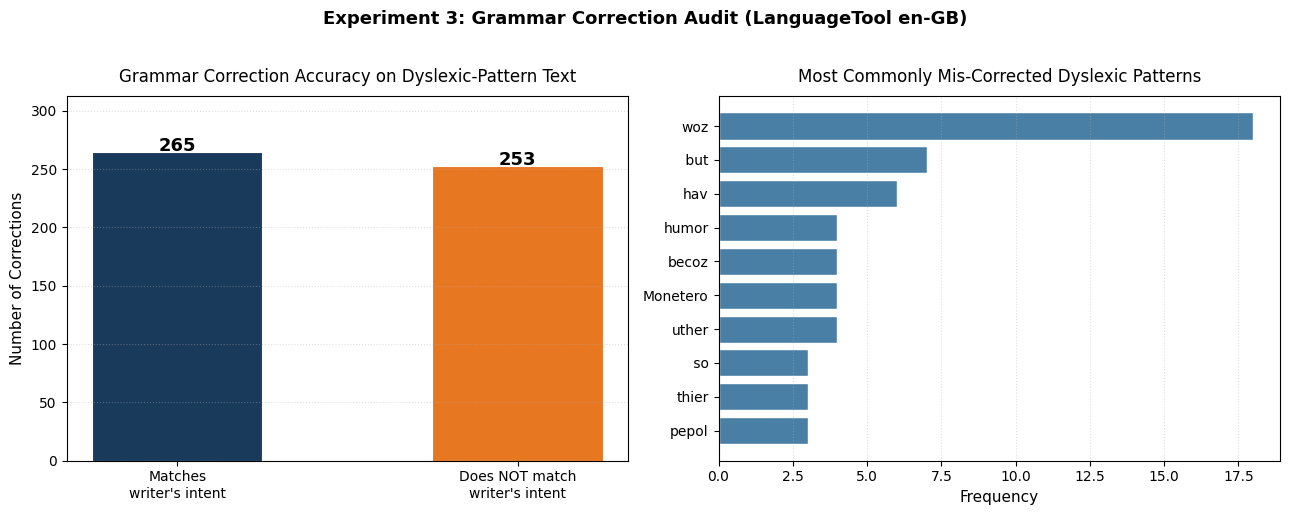


Figure 3 saved: experiment3_grammar.png


In [14]:
# CELL 14 — Experiment 3: Analysis & Visualisation

if len(corr_df) == 0:
    print("No corrections found in sample. Try increasing TEXT_CAP or sample size.")
else:
    total_corrections  = len(corr_df)
    intent_correct     = corr_df["intent_matched"].sum()
    intent_wrong       = total_corrections - intent_correct
    wrong_rate         = intent_wrong / total_corrections * 100

    print("=" * 60)
    print("EXPERIMENT 3 RESULTS: GRAMMAR CORRECTION AUDIT")
    print("=" * 60)
    print(f"Total correction suggestions : {total_corrections:,}")
    print(f"Corrections matching intent  : {intent_correct:,} ({100 - wrong_rate:.1f}%)")
    print(f"Corrections NOT matching     : {intent_wrong:,} ({wrong_rate:.1f}%)")
    print()

    # Most common wrong rules
    wrong_corrs = corr_df[~corr_df["intent_matched"]]
    if len(wrong_corrs) > 0:
        print("Most common rule IDs for wrong corrections:")
        print(wrong_corrs["rule_id"].value_counts().head(8).to_string())

    # ── Visualisation ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar: intent matched vs not
    labels  = ["Matches\nwriter's intent", "Does NOT match\nwriter's intent"]
    values  = [intent_correct, intent_wrong]
    colours = ["#1A3A5C", "#E87722"]

    bars = axes[0].bar(labels, values, color=colours, edgecolor="white",
                       linewidth=0.8, width=0.5)
    for bar, val in zip(bars, values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     str(val), ha="center", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Number of Corrections", fontsize=11)
    axes[0].set_title("Grammar Correction Accuracy on Dyslexic-Pattern Text", fontsize=12, pad=10)
    axes[0].grid(axis="y", linestyle=":", alpha=0.4)
    axes[0].set_ylim(0, max(values) * 1.18)

    # Bar: top wrong corrections
    if len(wrong_corrs) >= 5:
        top_wrong = wrong_corrs["dyslexic_word"].value_counts().head(10)
        axes[1].barh(top_wrong.index[::-1], top_wrong.values[::-1],
                     color="#4A7FA5", edgecolor="white")
        axes[1].set_xlabel("Frequency", fontsize=11)
        axes[1].set_title("Most Commonly Mis-Corrected Dyslexic Patterns", fontsize=12, pad=10)
        axes[1].grid(axis="x", linestyle=":", alpha=0.4)
    else:
        axes[1].text(0.5, 0.5, "Not enough wrong corrections\nto rank by frequency",
                     ha="center", va="center", transform=axes[1].transAxes, fontsize=11)
        axes[1].axis("off")

    plt.suptitle("Experiment 3: Grammar Correction Audit (LanguageTool en-GB)",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("experiment3_grammar.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nFigure 3 saved: experiment3_grammar.png")


## Cell 15 — Show Wrong Correction Examples

In [15]:
# CELL 15 — Show examples of wrong grammar corrections
# These are the most important qualitative findings in Experiment 3.
# Screenshot these for your article figures.

wrong_corrs = corr_df[~corr_df["intent_matched"]]

print(f"Found {len(wrong_corrs)} corrections that did NOT match the writer's intent.")
print()
print("Top examples (copy/screenshot these for your article):")
print("=" * 70)

for _, row in wrong_corrs.head(15).iterrows():
    print(f"\n  Dyslexic spelling : '{row['dyslexic_word']}'")
    print(f"  Tool suggested    : '{row['top_suggestion']}'")
    print(f"  All suggestions   : {row['all_suggestions']}")
    print(f"  Rule              : {row['rule_id']}")
    print(f"  Context           : {row['context']}")


Found 253 corrections that did NOT match the writer's intent.

Top examples (copy/screenshot these for your article):

  Dyslexic spelling : 'Spindell'
  Tool suggested    : 'Spin dell'
  All suggestions   : Spin dell
  Rule              : MORFOLOGIK_RULE_EN_GB
  Context           : ...hough several scenes of Wirey Spindell can be described as "over the...

  Dyslexic spelling : 'Spindell'
  Tool suggested    : 'Spin dell'
  All suggestions   : Spin dell
  Rule              : MORFOLOGIK_RULE_EN_GB
  Context           : ...sted comedy.<br /><br />Wirey Spindell is a great film with great di...

  Dyslexic spelling : 'dialog'
  Tool suggested    : 'dialogue'
  All suggestions   : dialogue
  Rule              : MORFOLOGIK_RULE_EN_GB
  Context           : ...ll is a great film with great dialog. I wouldn't say that this fil...

  Dyslexic spelling : 'it's'
  Tool suggested    : 'its'
  All suggestions   : its
  Rule              : IT_IS
  Context           : ...><br />If you can look beyon

---
# Combined Summary: Reading the Three Experiments Together


In [16]:
# CELL 16 — Combined summary table

print("=" * 65)
print("COMBINED AUDIT SUMMARY")
print("=" * 65)

# Experiment 1
flip_rate  = df["label_flipped"].mean() * 100
mean_delta = df["score_delta"].mean()
print(f"\nExperiment 1 — Sentiment Classifier (RoBERTa)")
print(f"  Label flip rate            : {flip_rate:.1f}%")
print(f"  Mean confidence drop       : {mean_delta:.4f}")

# Experiment 2
print(f"\nExperiment 2 — Readability Scores")
for col, label, _, _ in METRICS:
    delta = read_df[f"dys_{col}"].mean() - read_df[f"orig_{col}"].mean()
    flag  = " ⚠️" if abs(delta) > 1.0 else ""
    print(f"  {label:<35} delta = {delta:+.2f}{flag}")

# Experiment 3
if len(corr_df) > 0:
    wrong_rate = (~corr_df["intent_matched"]).mean() * 100
    print(f"\nExperiment 3 — Grammar Correction (LanguageTool)")
    print(f"  Corrections NOT matching intent : {wrong_rate:.1f}%")
    print(f"  Total correction suggestions    : {len(corr_df):,}")

print()
print("=" * 65)
print("All output files saved:")
print("  experiment1_sentiment_results.csv")
print("  experiment2_readability_results.csv")
print("  experiment3_grammar_results.csv")
print("  experiment1_sentiment.png")
print("  experiment2_readability.png")
print("  experiment3_grammar.png")


COMBINED AUDIT SUMMARY

Experiment 1 — Sentiment Classifier (RoBERTa)
  Label flip rate            : 2.4%
  Mean confidence drop       : 0.0026

Experiment 2 — Readability Scores
  Flesch-Kincaid Grade Level          delta = -0.03
  Gunning Fog Index                   delta = +0.01
  SMOG Index                          delta = -0.02
  Flesch Reading Ease                 delta = +0.24

Experiment 3 — Grammar Correction (LanguageTool)
  Corrections NOT matching intent : 48.8%
  Total correction suggestions    : 518

All output files saved:
  experiment1_sentiment_results.csv
  experiment2_readability_results.csv
  experiment3_grammar_results.csv
  experiment1_sentiment.png
  experiment2_readability.png
  experiment3_grammar.png


---

## References

1. Maas, A., et al. *Learning Word Vectors for Sentiment Analysis*. ACL (2011). https://ai.stanford.edu/~amaas/data/sentiment/
2. Loureiro, D., et al. *TimeLMs: Diachronic Language Models from Twitter*. ACL (2022). https://arxiv.org/abs/2202.03829
3. Rello, L., et al. *DysList: An Annotated Resource of Dyslexic Errors*. LREC Workshop (2012).
4. Sun, X., et al. *Adv-BERT: BERT is not Robust on Misspellings*. arXiv:2003.04985 (2020).
5. Piktus, A., et al. *Noisy Text Data: Achilles' Heel of BERT*. arXiv:2003.12932 (2020).
6. British Dyslexia Association. *Dyslexia Style Guide 2023*. https://www.bdadyslexia.org.uk
7. UK Government. *Equality Act 2010*. https://www.legislation.gov.uk/ukpga/2010/15/contents
8. Naber, D. *LanguageTool: A Proof of Concept for a Rule-Based Style and Grammar Checker*. EACL (2003).

---
*Immanuel Obani — Data Scientist (NLP & Responsible AI) | immanuelobani.com*
